**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v4 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/30/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/25/2025
* Finished Iteration on -06/30/2025-

In [220]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [221]:
# Import and load libs and packages
import pandas as pd
import seaborn as sns
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from rapidfuzz import process, fuzz

# Download NLTK stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rford\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [222]:
# Load base dataset here
df = pd.read_excel("2023_City.xlsx")

# Split into training (30%) and test (70%)
train_df = df.sample(frac=0.3, random_state=42)
test_df = df.drop(train_df.index)

In [223]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management","Public Works - Sanitation","Public Works - Street Services",
    "Public Works - Maint Svcs","Streets","Public Works-Operations","Public Works - Parks And Landscape ",
    "Public Works - Streets","Public Works-Corporate Yard","Public Works - Maintenance",
    "Public Works - Parks","Public Works Operations","Public Works - Refuse","Public Works/Solid Waste",
    "Public Works - Solid Waste","Public Works - Wastewater","Public Works/Street Maintenance",
    "War Memorial","Public Works - Right Of Way","Public Works - Utility Services", "Street Maintenance",
    "Public Works Parks","Grounds Maintenance","Public Works Yard",
    
]

filter_position_keywords = [
    "Motor Sweeper Operator","Public Works Ranger","Park Ranger","Administrative Assistant","Fitness instructor",
    "Administrative Intern","Equipment Operator","Crossing Guard","Park Lead","Plumber","Mechanic","Gardener",
    "Temporary","Chemist","Seasonal Aide","Plant Operator","Foreman Water","Solid Resources","Parks","Asphalt Worker",
    "Business Analyst","Human Resources","Parking","Facilities","Golf","Downtown","Stationary","Groundskeeper"
    "Laboratory Technician", "Building & Grounds Patrol Officer", "Patrol Officer", "Youth Job Corps Program Participant",
    "School Guard","Tree Trimmer", "Transit Coach Operator","General Laborer", "Street Inspector","Utility Worker","Custodial",
    "Office Specialist","Street Services","Maintenance","Accountant","City Worker","Sanitation","Graffiti"
    "Maintenance Supervisor","Wastewater Treatment Operator","Wastewater Treatment Mechanic","Office Assistant",
    "Recreational Leader", "Librarian", "Admin", "Clerk","Wastewater System Operator","Water Foreman",
    "Wastewater Conveyance Operator","Management Assistant","Street Maintenance Worker","Maintenance Aide",
    "Lot Operator","Public Works Maintenance Worker","Maintenance Worker","Project Assistant","Project Manager",
    "Tree Surgeon","Intern","Truck Driver","Solid Waste Equipment Operator","Refuse Operator","Refuse Collection Supervisor",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling","Management Analyst", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian","Maintenance Worker", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio","Irrigation Specialist",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk","Staff Assistant",
    "Customer Service", "Truck Operator", "Sanitation", "Painter","Water Utility Worker","Arborist"
    "Laborer", "Program Assistant","Staff Specialist","Refuse","Department Assistant","Landscape"
]


In [224]:
# Helper function to match keywords
def keyword_match(text, keywords):
    if pd.isna(text):
        return False
    return any(re.search(rf'\b{re.escape(k)}\b', str(text), re.IGNORECASE) for k in keywords)

# Label rows for training
def label_row(row):
    keep_dept = keyword_match(row['DepartmentOrSubdivision'], keep_dept_keywords)
    keep_pos = keyword_match(row['Position'], keep_position_keywords)
    filter_dept = keyword_match(row['DepartmentOrSubdivision'], filter_dept_keywords)
    filter_pos = keyword_match(row['Position'], filter_position_keywords)
    return int((keep_dept or keep_pos) and not (filter_dept or filter_pos))


In [225]:
# Apply labeling
train_df["label"] = train_df.apply(label_row, axis=1)

# Combine text for model training
train_df["combined_text"] = train_df["DepartmentOrSubdivision"].fillna('') + " " + train_df["Position"].fillna('')

# Show label distribution
train_df["label"].value_counts()


label
0    96508
1     6802
Name: count, dtype: int64

In [226]:
# Feature and Target Preparation

X = train_df["combined_text"]
y = train_df["label"]


In [227]:
# Create pipeline with TF-IDF + Random Forest
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=stopwords.words('english'), max_features=1000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train model
model.fit(X, y)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [228]:
# Combine text columns
test_df["combined_text"] = test_df["DepartmentOrSubdivision"].fillna('') + " " + test_df["Position"].fillna('')

# Predict using the trained model
test_df["predicted_label"] = model.predict(test_df["combined_text"])

# Filter the results
filtered_test_df = test_df[test_df["predicted_label"] == 1]
filtered_train_df = train_df[train_df["label"] == 1]
filtered_df = pd.concat([filtered_train_df, filtered_test_df], ignore_index=True)


# Display summary
print(f"Filtered rows: {len(filtered_df)} / {len(df)}")
filtered_df.head()



Filtered rows: 22409 / 344366


,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,label,combined_text,predicted_label
0,2023,City,Fullerton,Public Works - Engineering,Assistant Engineer,False,False,NaN,82744.0,105606.0,...,https://cityoffullerton.com/government/departm...,140311,2024-06-25,Orange,NaN,False,NaN,1.0,Public Works - Engineering Assistant Engineer,NaN
1,2023,City,Los Altos,Engineering,City Engineer,False,False,NaN,171030.0,207888.0,...,https://www.losaltosca.gov/hr,31255,2024-06-25,Santa Clara,NaN,False,NaN,1.0,Engineering City Engineer,NaN
2,2023,City,San Francisco,Municipal Transportation Agency,Transportation Planner III,False,False,NaN,118014.0,143416.0,...,www.sfdhr.org,843071,2024-06-25,San Francisco,NaN,True,NaN,1.0,Municipal Transportation Agency Transportation...,NaN
3,2023,City,Simi Valley,Environmental Services,Building Inspector II,False,False,NaN,62904.0,80203.0,...,https://www.simivalley.org/hr,124029,2024-06-25,Ventura,NaN,False,NaN,1.0,Environmental Services Building Inspector II,NaN
4,2023,City,Escondido,Planning,City Planner,False,False,NaN,115224.0,155546.0,...,https://www.escondido.gov/407/Human-Resources,150002,2024-06-25,San Diego,NaN,False,NaN,1.0,Planning City Planner,NaN


In [229]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [230]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


In [231]:
# Filters: Empty if not needed

# Specify the city to exclude
excluded_cities = ["Los Angeles"]
# Specify the county to exclude
excluded_counties = ["Los Angeles"]


In [232]:
# Aggregate and filter 
agg_city_counts = filtered_df.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts = filtered_df.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

filtered_city = filtered_df[~filtered_df['clean_city_name'].isin(excluded_cities)]
filtered_county = filtered_df[~filtered_df['clean_county_name'].isin(excluded_counties)]

agg_city_counts_filtered = filtered_city.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts_filtered = filtered_county.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered
#filtered_city
#filtered_county



In [233]:
# Bin ranges
agg_city_counts['city_personnel_bin'] = pd.cut(
    agg_city_counts['personnel_count_city'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)

agg_county_counts['county_personnel_bin'] = pd.cut(
    agg_county_counts['personnel_count_county'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)


In [234]:
# Read Files and load data
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")
county_geo = gpd.read_file("California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp")


In [235]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(
    agg_city_counts[['clean_city_name', 'personnel_count_city', 'city_personnel_bin']],
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

geo_city['has_data'] = ~geo_city['personnel_count_city'].isna()
geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

# Merge all needed data
geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill missing values for plotting
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)



In [236]:
# Merge with county_geo: Full
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

geo_county = county_geo.merge(
    agg_county_counts[['clean_county_name', 'personnel_count_county', 'county_personnel_bin']],
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with county_geo: Filtered
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill missing personnel counts with 0
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)

In [237]:
# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

In [238]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing data"}
    )
    legend = ax.get_legend()
    if legend:
        legend.set_title(title)

    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


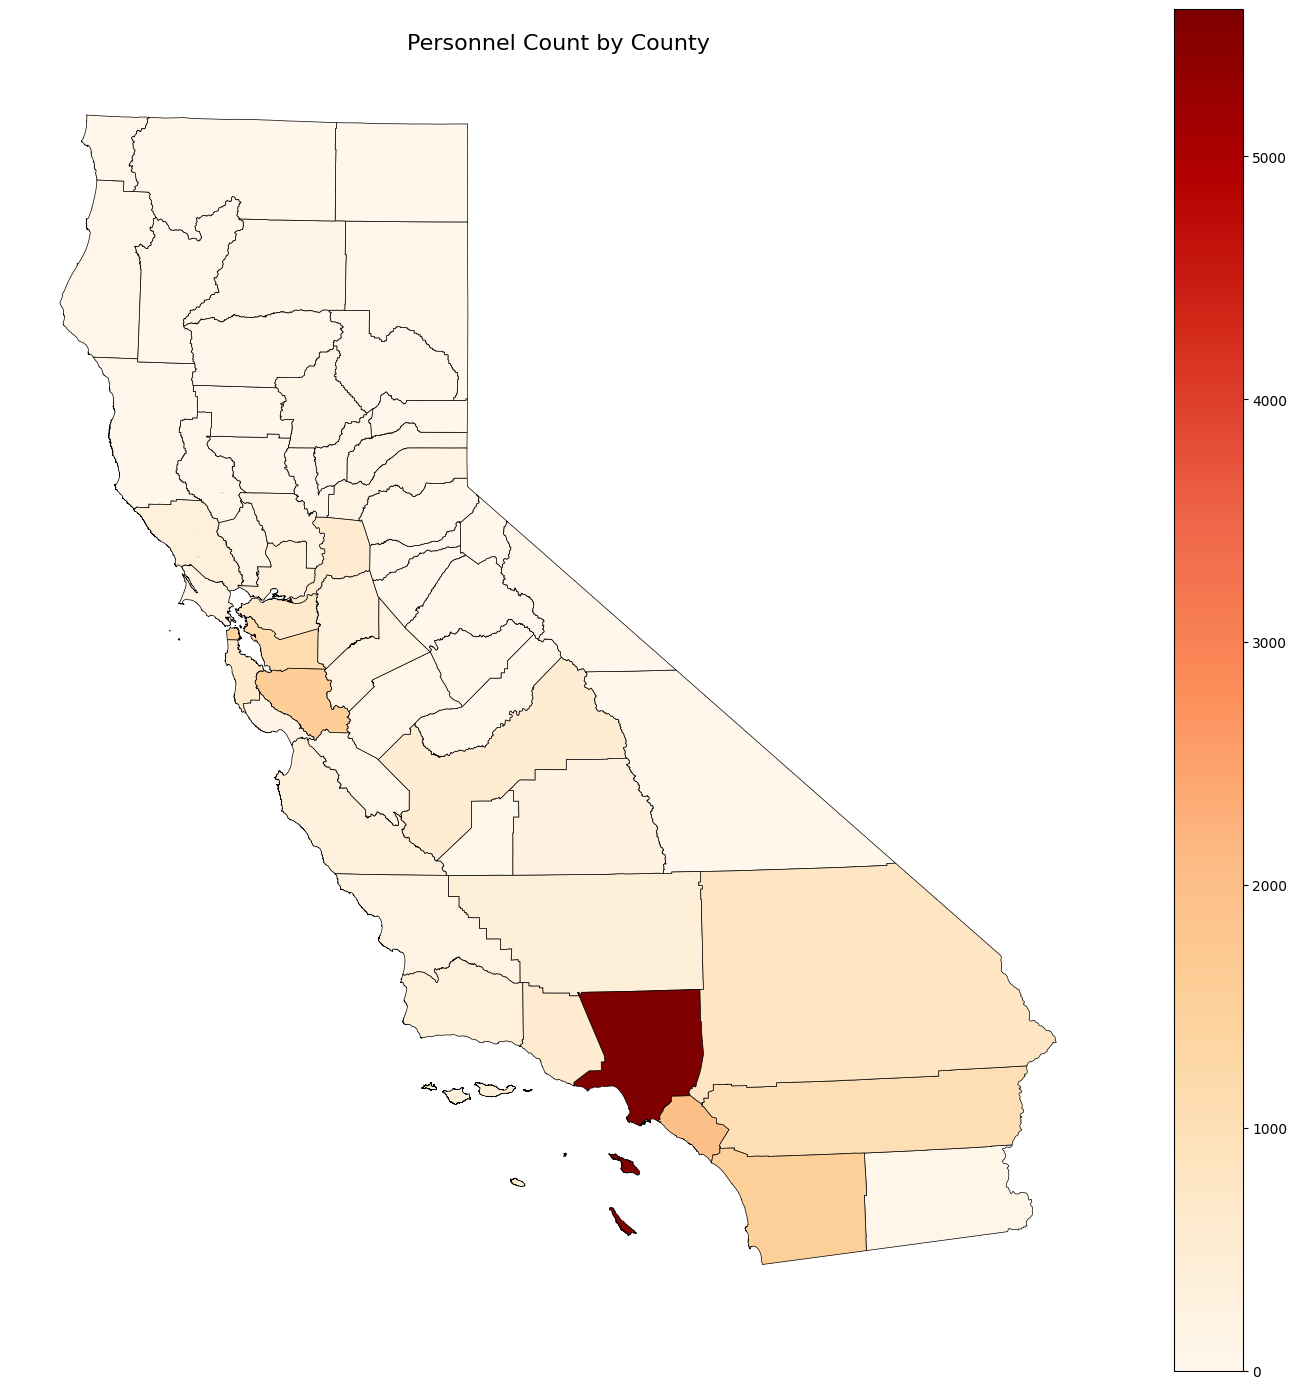

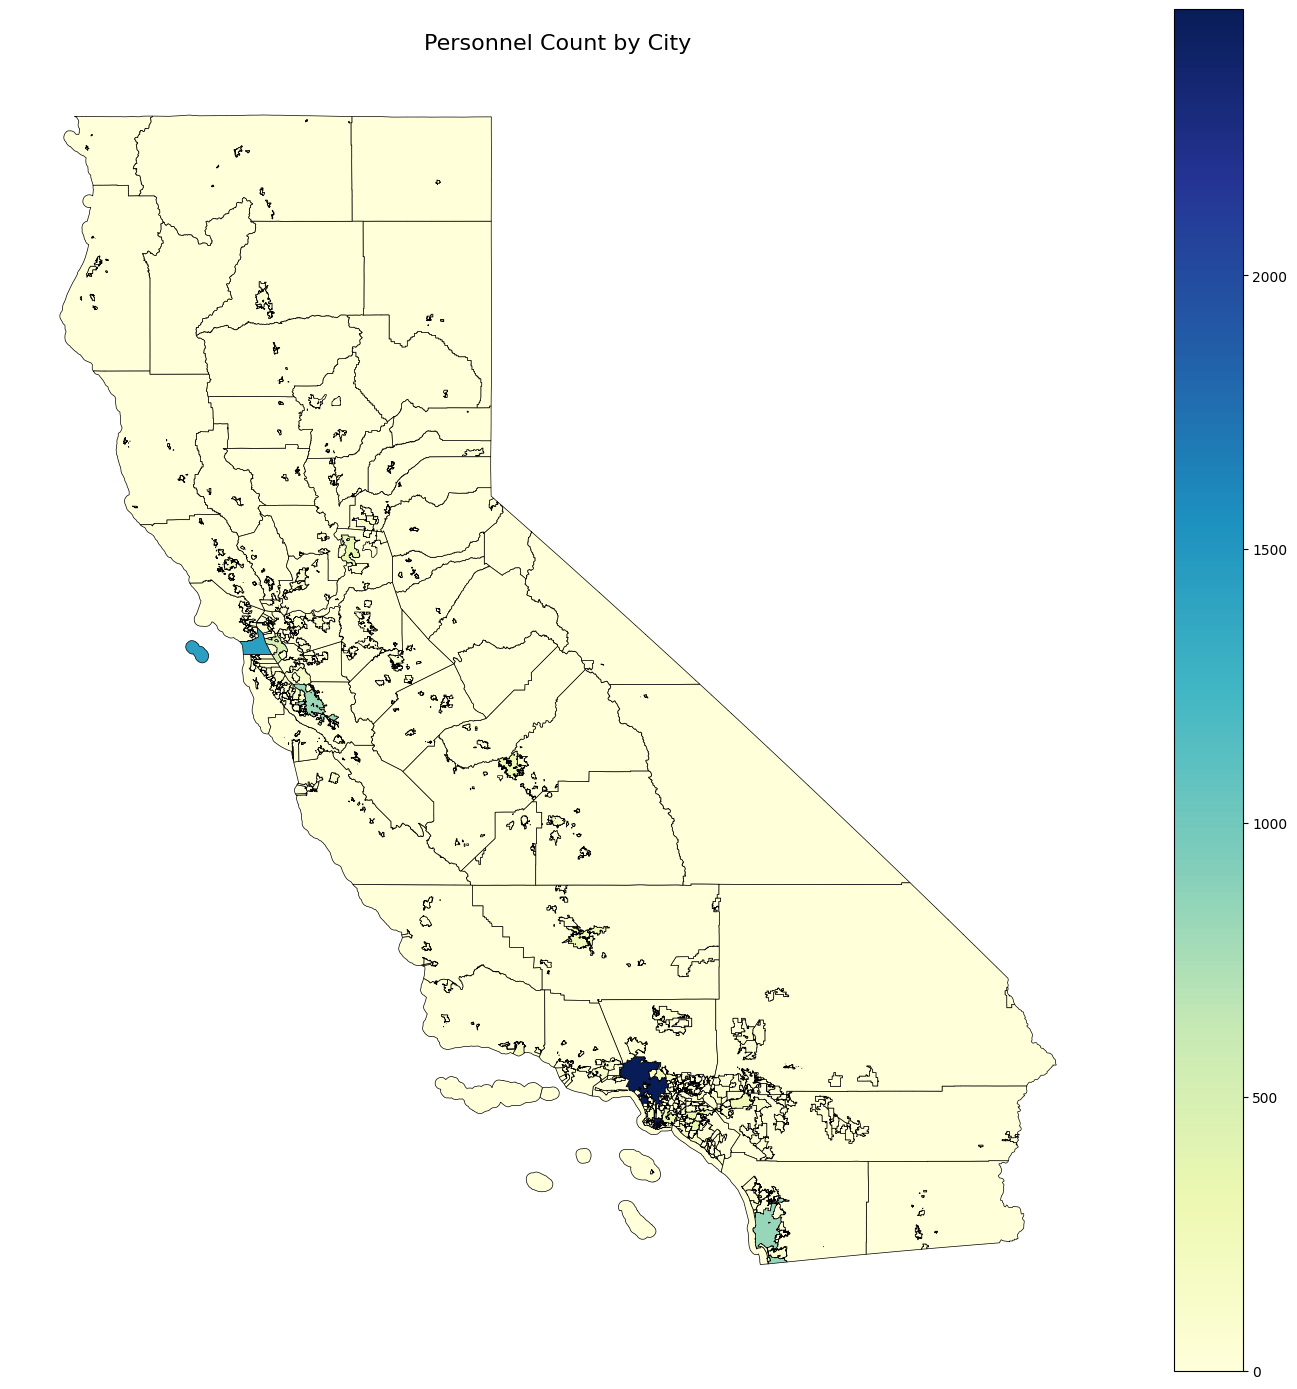

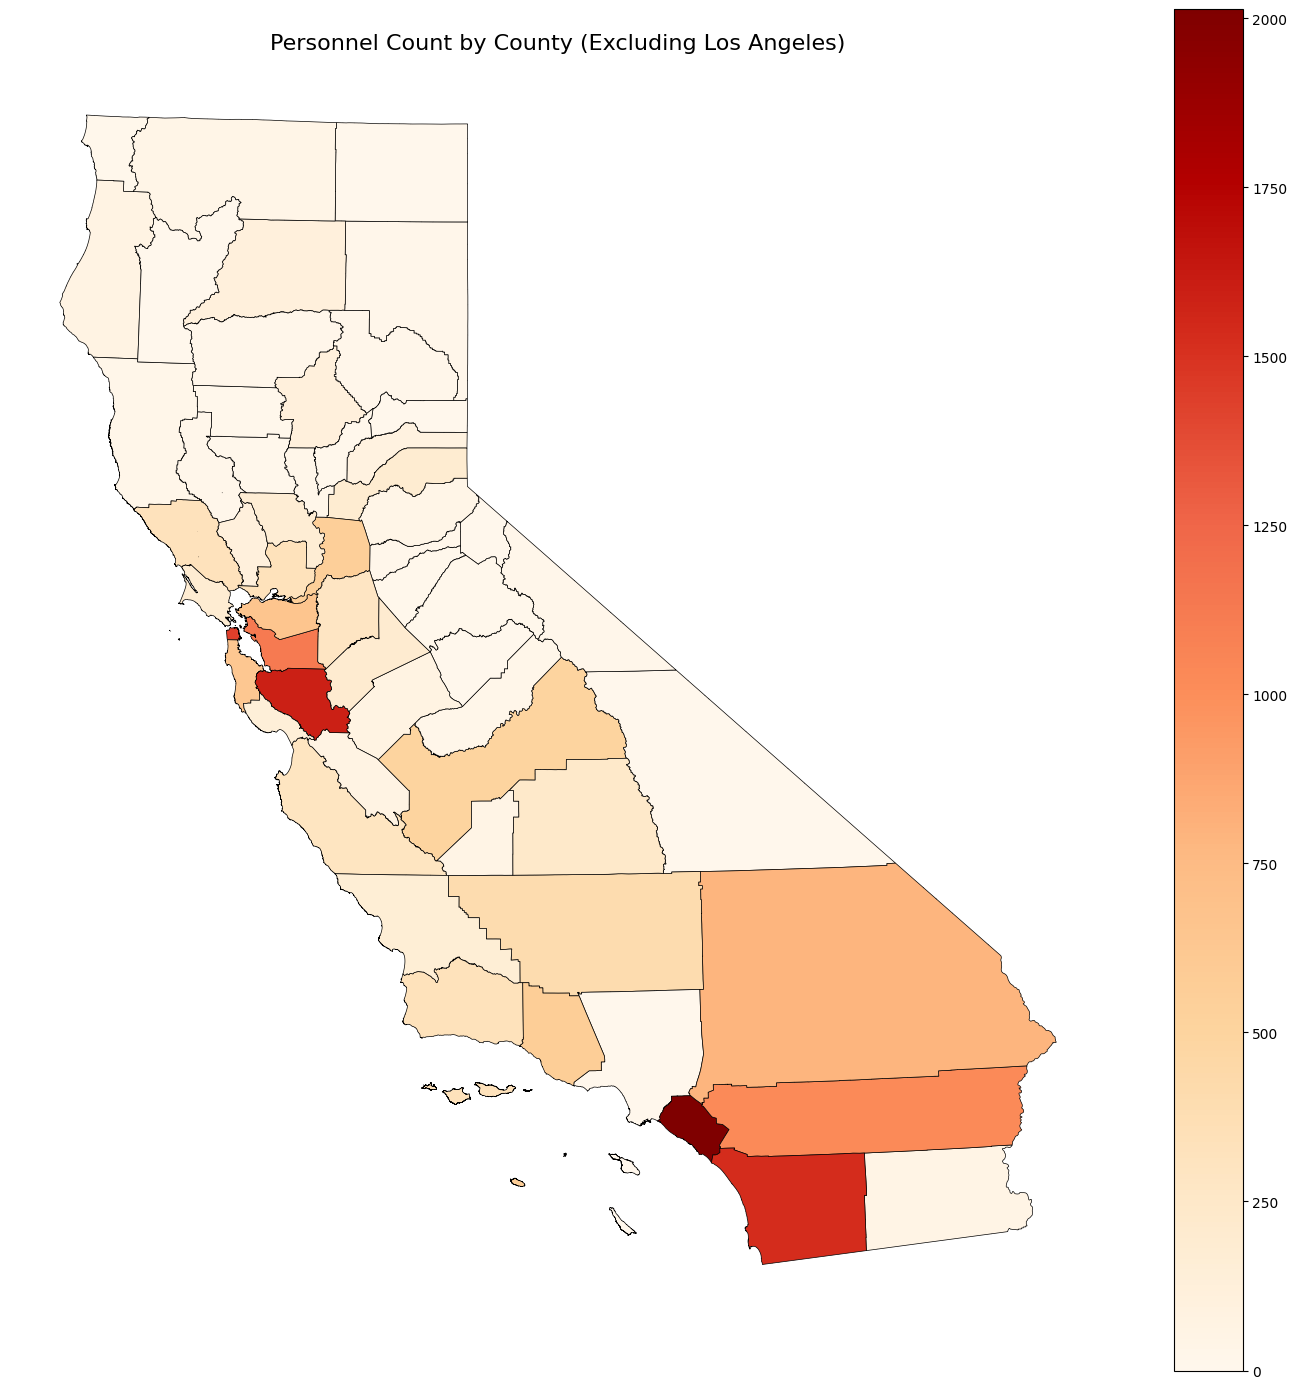

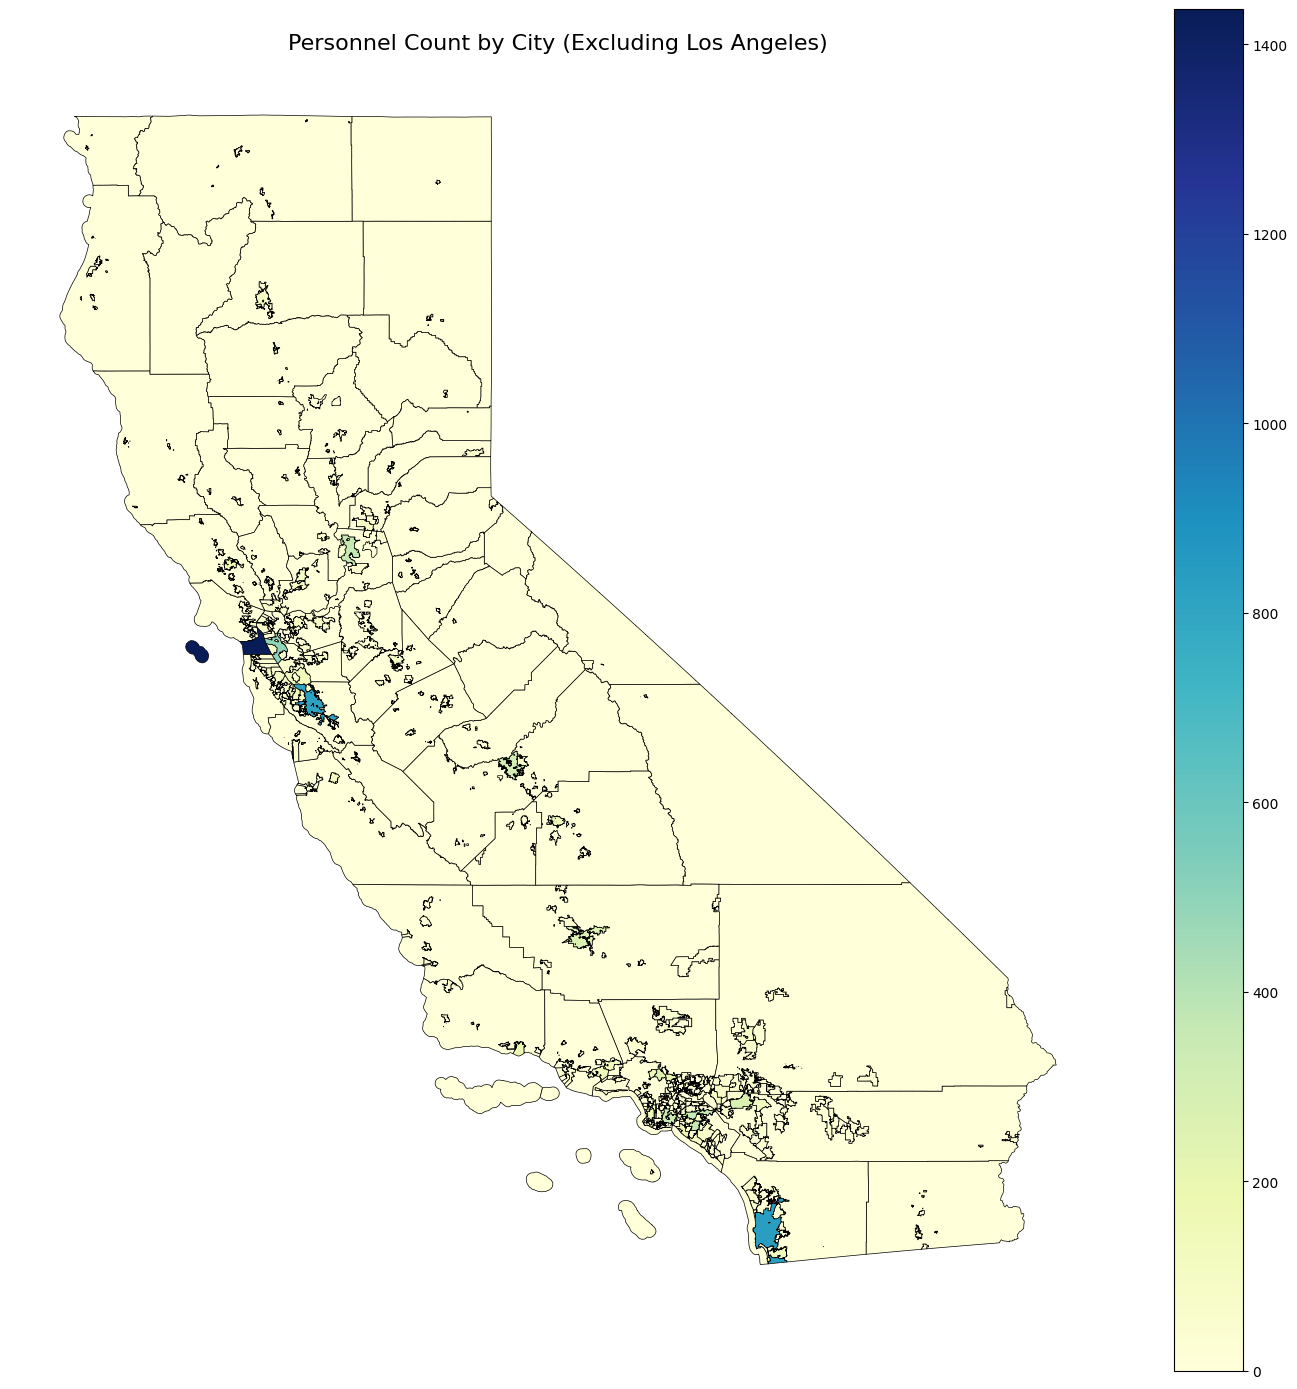

In [239]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title = f"Personnel Count by County (Excluding {', '.join(excluded_counties)})",
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title = f"Personnel Count by City (Excluding {', '.join(excluded_cities)})",
    cmap='YlGnBu'
)



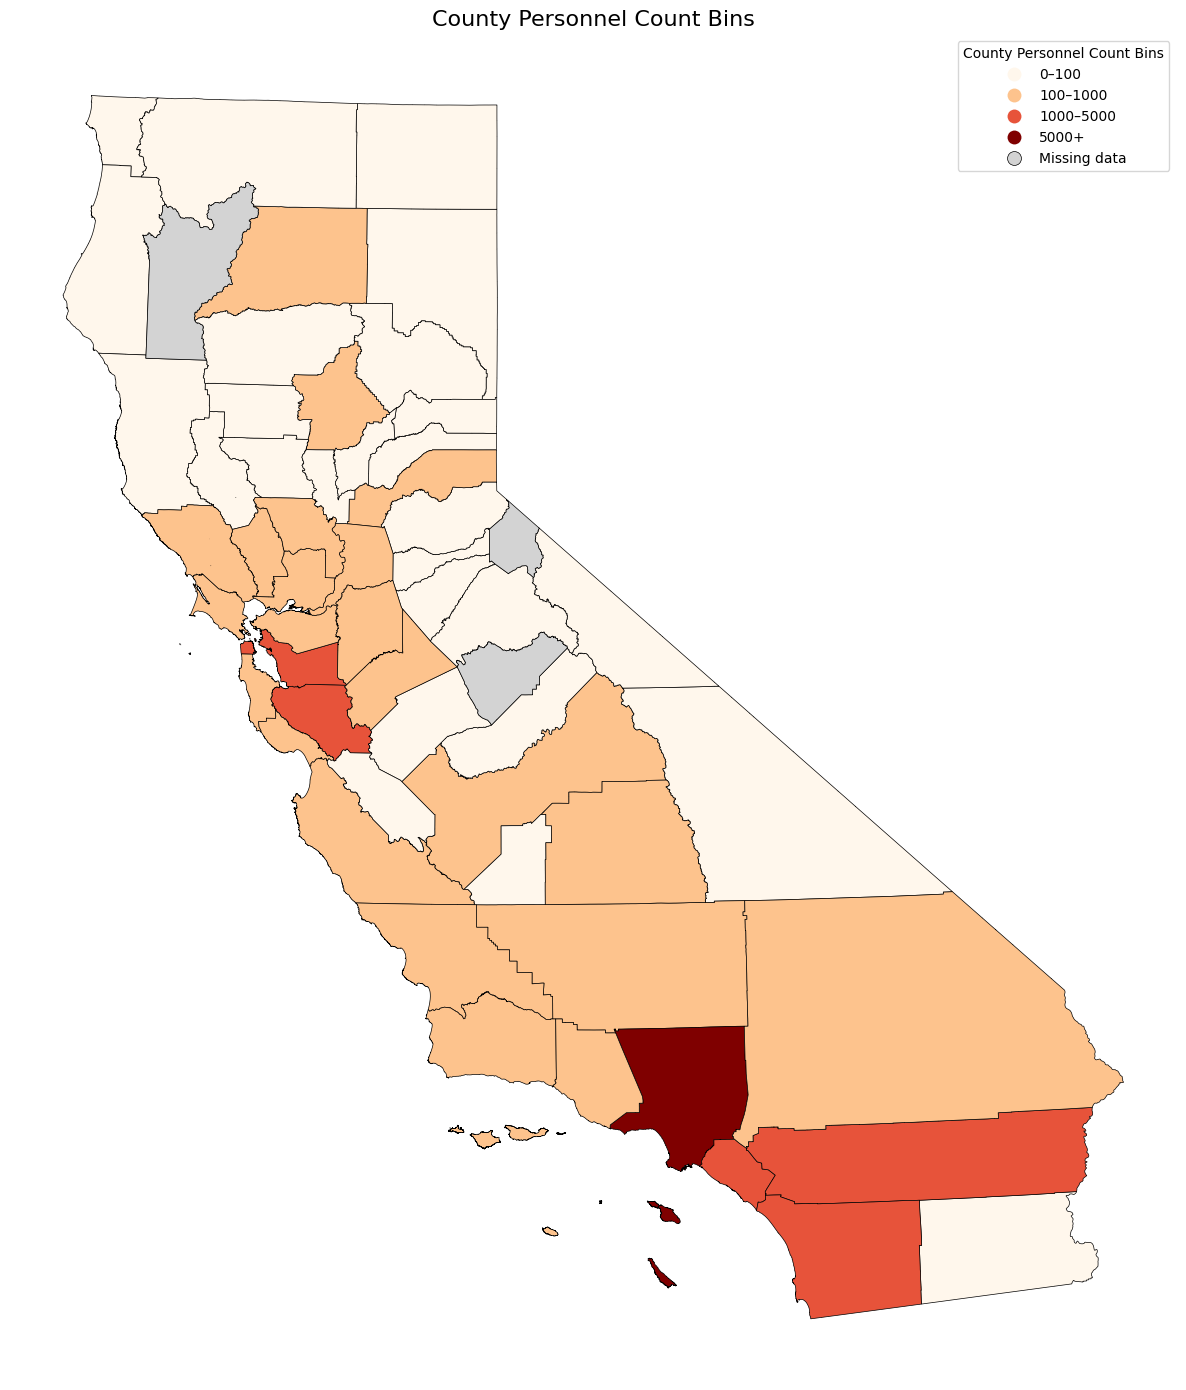

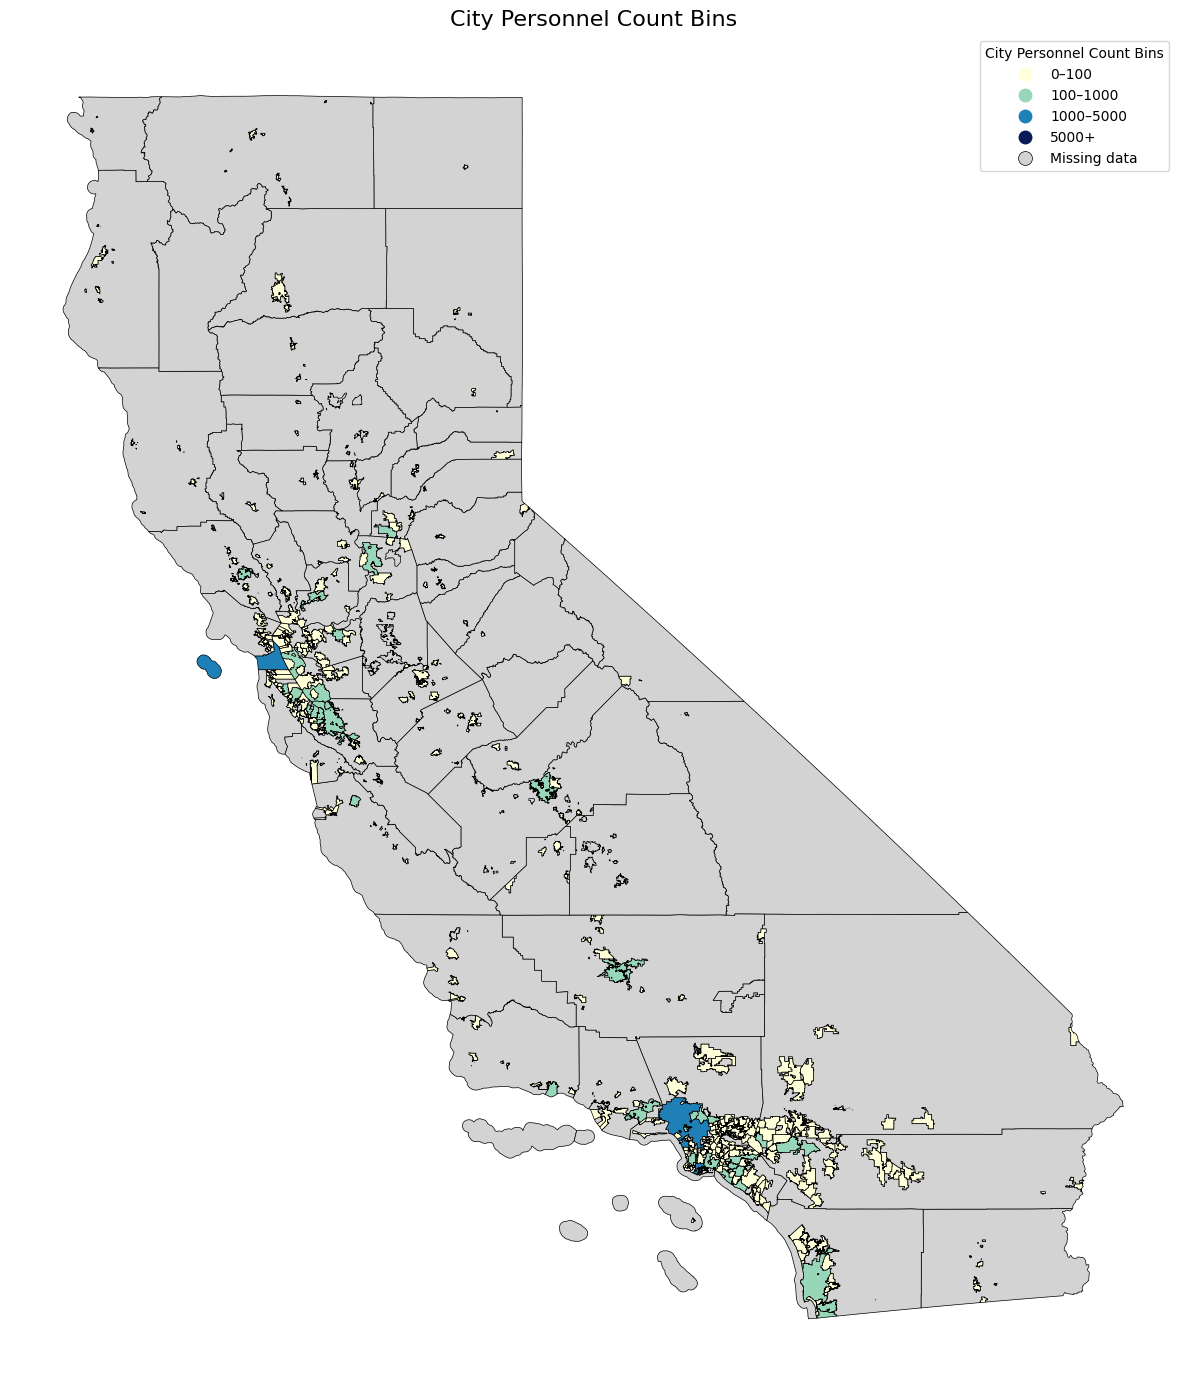

In [240]:
#  County Bins
plot_personnel_map(
    geo_county,
    column='county_personnel_bin',
    title='County Personnel Count Bins',
    cmap='OrRd'
)

#  City Bins
plot_personnel_map(
    geo_city,
    column='city_personnel_bin',
    title='City Personnel Count Bins',
    cmap='YlGnBu'
)

**<h3>General Statistics on Personnel Data Below**
* Dataframes: filtered_df, agg_city_counts, agg_county_counts, test_df

In [241]:
# Evaluating Model
y_test_true = test_df.apply(label_row, axis=1)  # True labels for test set
y_test_pred = test_df["predicted_label"]

In [242]:
# Classification Metrics
print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    225262
           1       0.96      0.95      0.96     15794

    accuracy                           0.99    241056
   macro avg       0.98      0.98      0.98    241056
weighted avg       0.99      0.99      0.99    241056



In [243]:
# F1-Score Discrete
f1 = f1_score(y_test_true, y_test_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9591


In [244]:
# Confusion Matrix Raw
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))


Confusion Matrix:
[[224714    548]
 [   735  15059]]


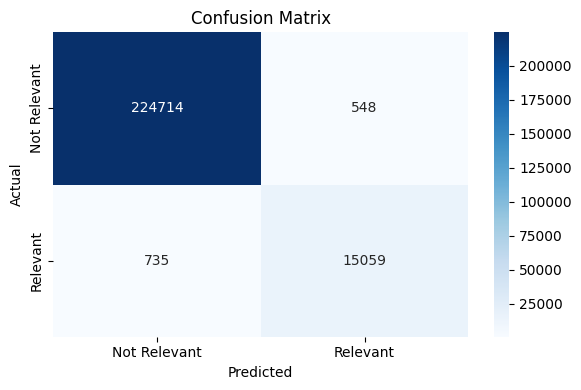

In [245]:
# Confusion Matrix Heatmap 
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Relevant", "Relevant"], yticklabels=["Not Relevant", "Relevant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

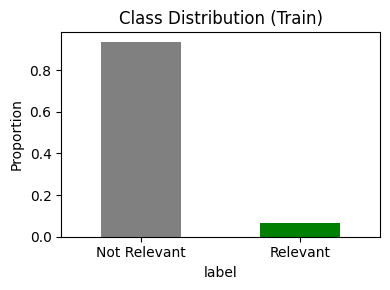

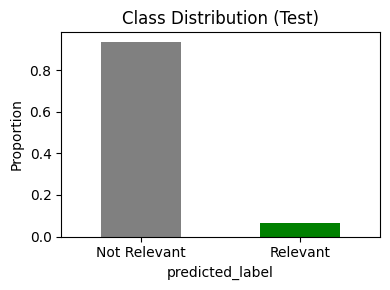

In [246]:
# Visualize the train imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
train_df["label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Train)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

# Visualize the test imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
test_df["predicted_label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Test)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [247]:
# Discrete proportions for each df
test_df["predicted_label"].value_counts(normalize=True)
#train_df["label"].value_counts(normalize=True)

predicted_label
0    0.935256
1    0.064744
Name: proportion, dtype: float64

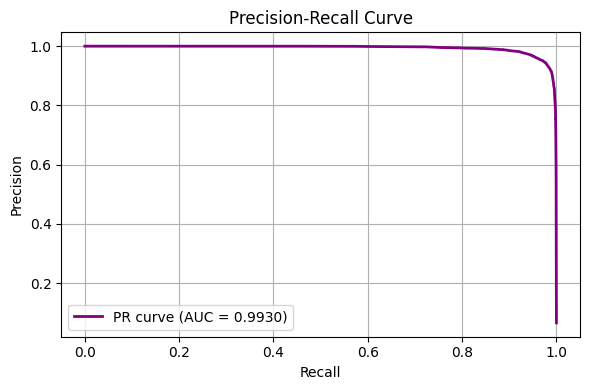

In [248]:
# Precision-Recall Curve
y_test_proba = model.predict_proba(test_df["combined_text"])[:, 1]  # Probabilities for class 1

precision, recall, thresholds = precision_recall_curve(y_test_true, y_test_proba)
pr_auc = average_precision_score(y_test_true, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.tight_layout()
plt.show()

In [249]:
# Check the Position and DepartmentOrSubdivision columns' stats here

#filtered_df.groupby('clean_city_name')['Position'].nunique().sort_values(ascending=False).head(10)
filtered_df['Position'].value_counts().head(15)

Position
Associate Planner                526
Senior Planner                   450
Assistant Engineer               373
Assistant Planner                344
Associate Engineer               340
Planning Commissioner            325
Building Inspector               292
Senior Civil Engineer            282
Permit Technician                218
Assistant Engineer - Civil       200
Building Mechanical Inspector    195
Building Inspector II            190
Code Enforcement Officer         176
Principal Planner                173
City Planner                     172
Name: count, dtype: int64

In [250]:
# Cities Represented
print("Total Cities/Unincorporated Areas Represented: ", filtered_df['EmployerName'].dropna().nunique())
# Counties Represented
print("Total Counties Represented: ", filtered_df['EmployerCounty'].dropna().nunique())
# Total Positions
print("Total Positions:", filtered_df['Position'].value_counts().sum())
print("Total Unique Positions:", filtered_df['Position'].dropna().nunique())
# Departments / Subdivisions
print("Total Unique Depts:", filtered_df['DepartmentOrSubdivision'].dropna().nunique()
)

Total Cities/Unincorporated Areas Represented:  472
Total Counties Represented:  55
Total Positions: 22409
Total Unique Positions: 4211
Total Unique Depts: 603


In [251]:
missing_cities = geo_city.loc[~geo_city['has_data'], 'clean_name']
print(f"{len(missing_cities)} cities present in shapefile but missing personnel data:")
print(missing_cities.unique())

739 cities present in shapefile but missing personnel data:
['Unincorporated' 'Amador City' 'Firebaugh' 'California' 'Bradbury'
 'Hidden Hills' 'La Cañada Flintridge' 'Point Arena' 'Del Rey Oaks'
 'Mountain House' 'Paso Robles' 'Atherton' 'Colma' 'Dorris' 'Mount Shasta'
 'Tehama' 'Ventura']


In [252]:
# Most workers per city
city_counts = filtered_df['clean_city_name'].value_counts()
print("Top 5 Cities by Worker Count:\n", city_counts.head(5))

# Least workers (but drop NaNs first)
print("\nBottom 5 Cities by Worker Count:\n", city_counts[city_counts > 0].tail(5))
print("\nNAs:\n", city_counts.isna().sum())


Top 5 Cities by Worker Count:
 clean_city_name
Los Angeles      2486
San Francisco    1437
San Diego         835
San Jose          815
Oakland           497
Name: count, dtype: int64

Bottom 5 Cities by Worker Count:
 clean_city_name
Lindsay        1
Maricopa       1
San Joaquin    1
Trinidad       1
Westmorland    1
Name: count, dtype: int64

NAs:
 0


In [253]:
# Most workers per county
county_counts = filtered_df['clean_county_name'].value_counts()
print("Top 10 Counties by Worker Count:\n", county_counts.head(10))

# Least workers
print("\nBottom 10 Counties by Worker Count:\n", county_counts[county_counts > 0].tail(10))
print("\nNAs:\n", county_counts.isna().sum())


Top 10 Counties by Worker Count:
 clean_county_name
Los Angeles       5606
Orange            2014
Santa Clara       1594
San Diego         1534
San Francisco     1437
Alameda           1128
Riverside         1026
San Bernardino     791
Contra Costa       660
San Mateo          637
Name: count, dtype: int64

Bottom 10 Counties by Worker Count:
 clean_county_name
Plumas       16
Yuba         15
Glenn         9
Tuolumne      9
Del Norte     9
Colusa        8
Calaveras     8
Modoc         4
Inyo          2
Sierra        2
Name: count, dtype: int64

NAs:
 0


In [254]:
g = 10  # Change as needed

# Cities with < g positions
cities_under_g = city_counts[city_counts < 3]
print(f"\nNumber of cities with fewer than {g} positions: {len(cities_under_g)}")
print(cities_under_g.head(10))



Number of cities with fewer than 10 positions: 21
clean_city_name
Dos Palos        2
Colfax           2
Fort Jones       2
Rolling Hills    2
Bishop           2
Villa Park       2
Sand City        2
Live Oak         2
Loyalton         2
Ione             2
Name: count, dtype: int64


In [255]:
b = 25 # Change as needed

# Counties with < b positions
counties_under_b = county_counts[county_counts < b]
print(f"\nNumber of counties with fewer than {b} positions: {len(counties_under_b)}")
print(counties_under_b.head(10))


Number of counties with fewer than 25 positions: 16
clean_county_name
Mendocino    24
Lake         23
Amador       21
Mono         21
Tehama       18
Lassen       18
Plumas       16
Yuba         15
Glenn         9
Tuolumne      9
Name: count, dtype: int64


In [256]:
# Missing city name
missing_city = filtered_df['clean_city_name'].isna().sum()
print(f"Rows with missing city name: {missing_city}")

# Missing county name
missing_county = filtered_df['clean_county_name'].isna().sum()
print(f"Rows with missing county name: {missing_county}")

# Optionally: View rows
#filtered_df[filtered_df['clean_city_name'].isna() | filtered_df['clean_county_name'].isna()]


Rows with missing city name: 0
Rows with missing county name: 0


In [257]:
# View Distributions
print("City Personnel Bins Distribution")
print(agg_city_counts['city_personnel_bin'].value_counts().sort_index())

print("County Personnel Bin Distribution")
print(agg_county_counts['county_personnel_bin'].value_counts().sort_index())

City Personnel Bins Distribution
city_personnel_bin
0–100        432
100–1000      38
1000–5000      2
5000+          0
Name: count, dtype: int64
County Personnel Bin Distribution
county_personnel_bin
0–100        26
100–1000     22
1000–5000     6
5000+         1
Name: count, dtype: int64
